# Chest X-Ray Pneumonia Detection
## Exploratory Data Analysis (EDA)

This notebook explores the Chest X-ray dataset before training a Convolutional Neural Network (CNN). The goal is to understand the dataset distribution, inspect sample images, analyze image dimensions, and identify any class imbalance.

In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# Import project configuration
import sys
sys.path.append("../src")

from config import TRAIN_DIR, VAL_DIR, TEST_DIR

In [8]:
train_normal = os.listdir(os.path.join(TRAIN_DIR, "NORMAL"))
train_pneumonia = os.listdir(os.path.join(TRAIN_DIR, "PNEUMONIA"))

val_normal = os.listdir(os.path.join(VAL_DIR, "NORMAL"))
val_pneumonia = os.listdir(os.path.join(VAL_DIR, "PNEUMONIA"))

test_normal = os.listdir(os.path.join(TEST_DIR, "NORMAL"))
test_pneumonia = os.listdir(os.path.join(TEST_DIR, "PNEUMONIA"))

In [9]:
print("="*55)
print("CHEST X-RAY DATASET SUMMARY")
print("="*55)

print("\nTraining Set")
print(f"NORMAL     : {len(train_normal)}")
print(f"PNEUMONIA : {len(train_pneumonia)}")

print("\nValidation Set")
print(f"NORMAL     : {len(val_normal)}")
print(f"PNEUMONIA : {len(val_pneumonia)}")

print("\nTesting Set")
print(f"NORMAL     : {len(test_normal)}")
print(f"PNEUMONIA : {len(test_pneumonia)}")

print("\nTotal Images :", len(train_normal)+len(train_pneumonia)+
      len(val_normal)+len(val_pneumonia)+
      len(test_normal)+len(test_pneumonia))

CHEST X-RAY DATASET SUMMARY

Training Set
NORMAL     : 1341
PNEUMONIA : 3875

Validation Set
NORMAL     : 8
PNEUMONIA : 8

Testing Set
NORMAL     : 234
PNEUMONIA : 390

Total Images : 5856


## Class Distribution

The graph below shows the number of images belonging to each class in the training dataset.

A balanced dataset generally helps a model learn both classes equally well.

If one class contains significantly more samples than the other, class weights can be used during training to reduce prediction bias.

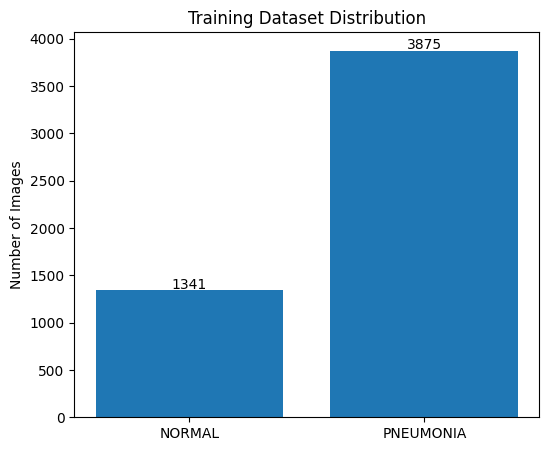

In [10]:
plt.figure(figsize=(6,5))

classes = ["NORMAL","PNEUMONIA"]
counts = [len(train_normal), len(train_pneumonia)]

plt.bar(classes, counts)

plt.title("Training Dataset Distribution")
plt.ylabel("Number of Images")

for i,v in enumerate(counts):
    plt.text(i, v+20, str(v), ha='center')

plt.savefig("../outputs/class_distribution.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

## Sample Chest X-rays

The following images are randomly selected from the training dataset.

Visual inspection helps understand the differences between healthy lungs and lungs affected by pneumonia before training the CNN.

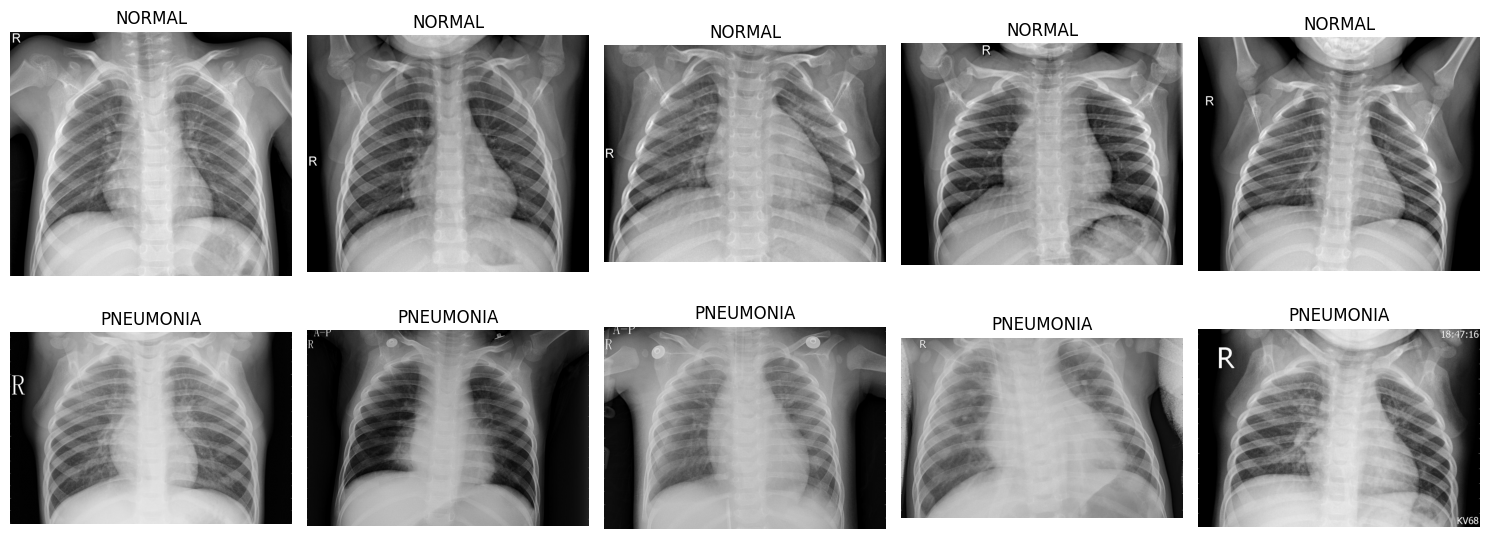

In [11]:
fig, axes = plt.subplots(2,5, figsize=(15,6))

# normal
for i in range(5):

    img_path = os.path.join(
        TRAIN_DIR,
        "NORMAL",
        random.choice(train_normal)
    )

    img = plt.imread(img_path)

    axes[0,i].imshow(img, cmap="gray")
    axes[0,i].set_title("NORMAL")
    axes[0,i].axis("off")

# pneumonia
for i in range(5):

    img_path = os.path.join(
        TRAIN_DIR,
        "PNEUMONIA",
        random.choice(train_pneumonia)
    )

    img = plt.imread(img_path)

    axes[1,i].imshow(img, cmap="gray")
    axes[1,i].set_title("PNEUMONIA")
    axes[1,i].axis("off")

plt.tight_layout()

plt.savefig("../outputs/sample_images.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Observations

Some noticeable differences include:

- Healthy lungs generally appear darker because they are filled with air.
- Pneumonia-affected lungs often contain white cloudy regions caused by inflammation and fluid accumulation.
- The severity and location of pneumonia vary across patients.
- Image quality and orientation also vary throughout the dataset.

In [12]:
normal_img = Image.open(
    os.path.join(TRAIN_DIR,"NORMAL",random.choice(train_normal))
)

pneumonia_img = Image.open(
    os.path.join(TRAIN_DIR,"PNEUMONIA",random.choice(train_pneumonia))
)

print("Sample NORMAL image size :", normal_img.size)
print("Sample PNEUMONIA image size :", pneumonia_img.size)

Sample NORMAL image size : (1766, 1287)
Sample PNEUMONIA image size : (1392, 824)


## Why are images resized?

The original Chest X-ray images have different resolutions.

Deep learning models require all input images to have the same dimensions.

Therefore, every image is resized to **128 × 128 pixels** (or **224 × 224 pixels**, depending on the experiment) before being passed to the CNN.